In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

In [2]:
# use raw strings so backslashes are not interpreted as escape codes
df_customers = pd.read_csv(r'D:\Credit Risk Modelling\Data\raw\customers.csv')
df_loans = pd.read_csv(r'D:\Credit Risk Modelling\Data\raw\loans.csv')
df_bureau = pd.read_csv(r'D:\Credit Risk Modelling\Data\raw\bureau_data.csv')

In [3]:
df_customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [4]:
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [5]:
df_bureau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [6]:
print("Number of rows and columns in customers dataset:", df_customers.shape)
print("Number of rows and columns in loans dataset:", df_loans.shape)
print("Number of rows and columns in bureau dataset:", df_bureau.shape)

Number of rows and columns in customers dataset: (50000, 12)
Number of rows and columns in loans dataset: (50000, 15)
Number of rows and columns in bureau dataset: (50000, 8)


In [7]:
print("Columns in customers dataset:", df_customers.columns.tolist())
print("Columns in loans dataset:", df_loans.columns.tolist())
print("Columns in bureau dataset:", df_bureau.columns.tolist())

Columns in customers dataset: ['cust_id', 'age', 'gender', 'marital_status', 'employment_status', 'income', 'number_of_dependants', 'residence_type', 'years_at_current_address', 'city', 'state', 'zipcode']
Columns in loans dataset: ['loan_id', 'cust_id', 'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'disbursal_date', 'installment_start_dt', 'default']
Columns in bureau dataset: ['cust_id', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio']


In [8]:
### Merging df_customers and df_loans on 'customer_id'
df = pd.merge(df_customers, df_loans, on='cust_id', how='inner')

In [9]:
### Merging df and df_bureau on 'customer_id'
df = pd.merge(df, df_bureau, on='cust_id', how='inner')

In [10]:
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [11]:
df.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio'],
      dtype='str')

In [12]:
# derive numeric/categorical lists and drop identifier columns
Numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
Categorical_cols = [col for col in cat_cols if col not in ['cust_id', 'loan_id']]

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21332\3369284540.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [13]:
print("Columns in the merged dataset:", df.columns.to_list())

Columns in the merged dataset: ['cust_id', 'age', 'gender', 'marital_status', 'employment_status', 'income', 'number_of_dependants', 'residence_type', 'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id', 'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'disbursal_date', 'installment_start_dt', 'default', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio']


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  str    
 13  loan_purpose               

In [15]:
### Converting defaulted column to binary
df['default'] = df['default'].astype(int)

In [16]:
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

From the default value count we can conclude
 - There is a class imbalance
 - Only 8.5% are in minority sector

### Train-Test Splitting Dataset

In [17]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [19]:
print("The number of rows and columns in the train dataset:", df_train.shape)
print("The number of rows and columns in the test dataset:", df_test.shape)

The number of rows and columns in the train dataset: (37500, 33)
The number of rows and columns in the test dataset: (12500, 33)


### Data Cleaning

#### 1. Checking Null Values

In [20]:
print("Null values in the train dataset:\n", df_train.isnull().sum())

Null values in the train dataset:
 cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_mo

In [21]:
print("Unique values in residence_type column:",df_train.residence_type.unique().tolist())

Unique values in residence_type column: ['Owned', 'Mortgage', 'Rented', nan]


In [22]:
print("Value counts in residence_type column:\n", df_train.residence_type.value_counts())

Value counts in residence_type column:
 residence_type
Owned       21114
Mortgage     8901
Rented       7437
Name: count, dtype: int64


In [23]:
mode_residence = df_train['residence_type'].mode()[0]
mode_residence

'Owned'

In [24]:
df_train = df_train.fillna(mode_residence, inplace=True)
df_test = df_test.fillna(mode_residence, inplace=True)

In [25]:
print("Unique values in residence_type column(train):",df_train.residence_type.unique().tolist())
print("Unique values in residence_type column(test):",df_test.residence_type.unique().tolist())

Unique values in residence_type column(train): ['Owned', 'Mortgage', 'Rented']
Unique values in residence_type column(test): ['Owned', 'Rented', 'Mortgage']


Filled the NaN Values in train and test Dataset by the most frequent values in the catgeory
- Most Frequent Values = Owned

#### 2. Checking Duplicate Values

In [26]:
print("Duplicate rows in the train dataset:", df_train.duplicated().sum())
print("Duplicate rows in the test dataset:", df_test.duplicated().sum())

Duplicate rows in the train dataset: 0
Duplicate rows in the test dataset: 0


There is no Duplicate Values in the train and test Datasets

### 3. Outlier Detection

In [27]:
print("Numerical columns in the train dataset:\n", df_train.select_dtypes(include=np.number).columns.tolist())
print("Categorical columns in the train dataset:\n", df_train.select_dtypes(include='object').columns.tolist())

Numerical columns in the train dataset:
 ['age', 'income', 'number_of_dependants', 'years_at_current_address', 'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default']
Categorical columns in the train dataset:
 ['cust_id', 'gender', 'marital_status', 'employment_status', 'residence_type', 'city', 'state', 'loan_id', 'loan_purpose', 'loan_type', 'disbursal_date', 'installment_start_dt']


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21332\2262703973.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns in the train dataset:\n", df_train.select_dtypes(include='object').columns.tolist())


In [28]:
Numerical_cols = df_train.select_dtypes(include=np.number).columns.tolist()
Categorical_cols = df_train.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in Categorical_cols if col not in ['cust_id', 'loan_id']]


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21332\161916664.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_cols = df_train.select_dtypes(include='object').columns.tolist()


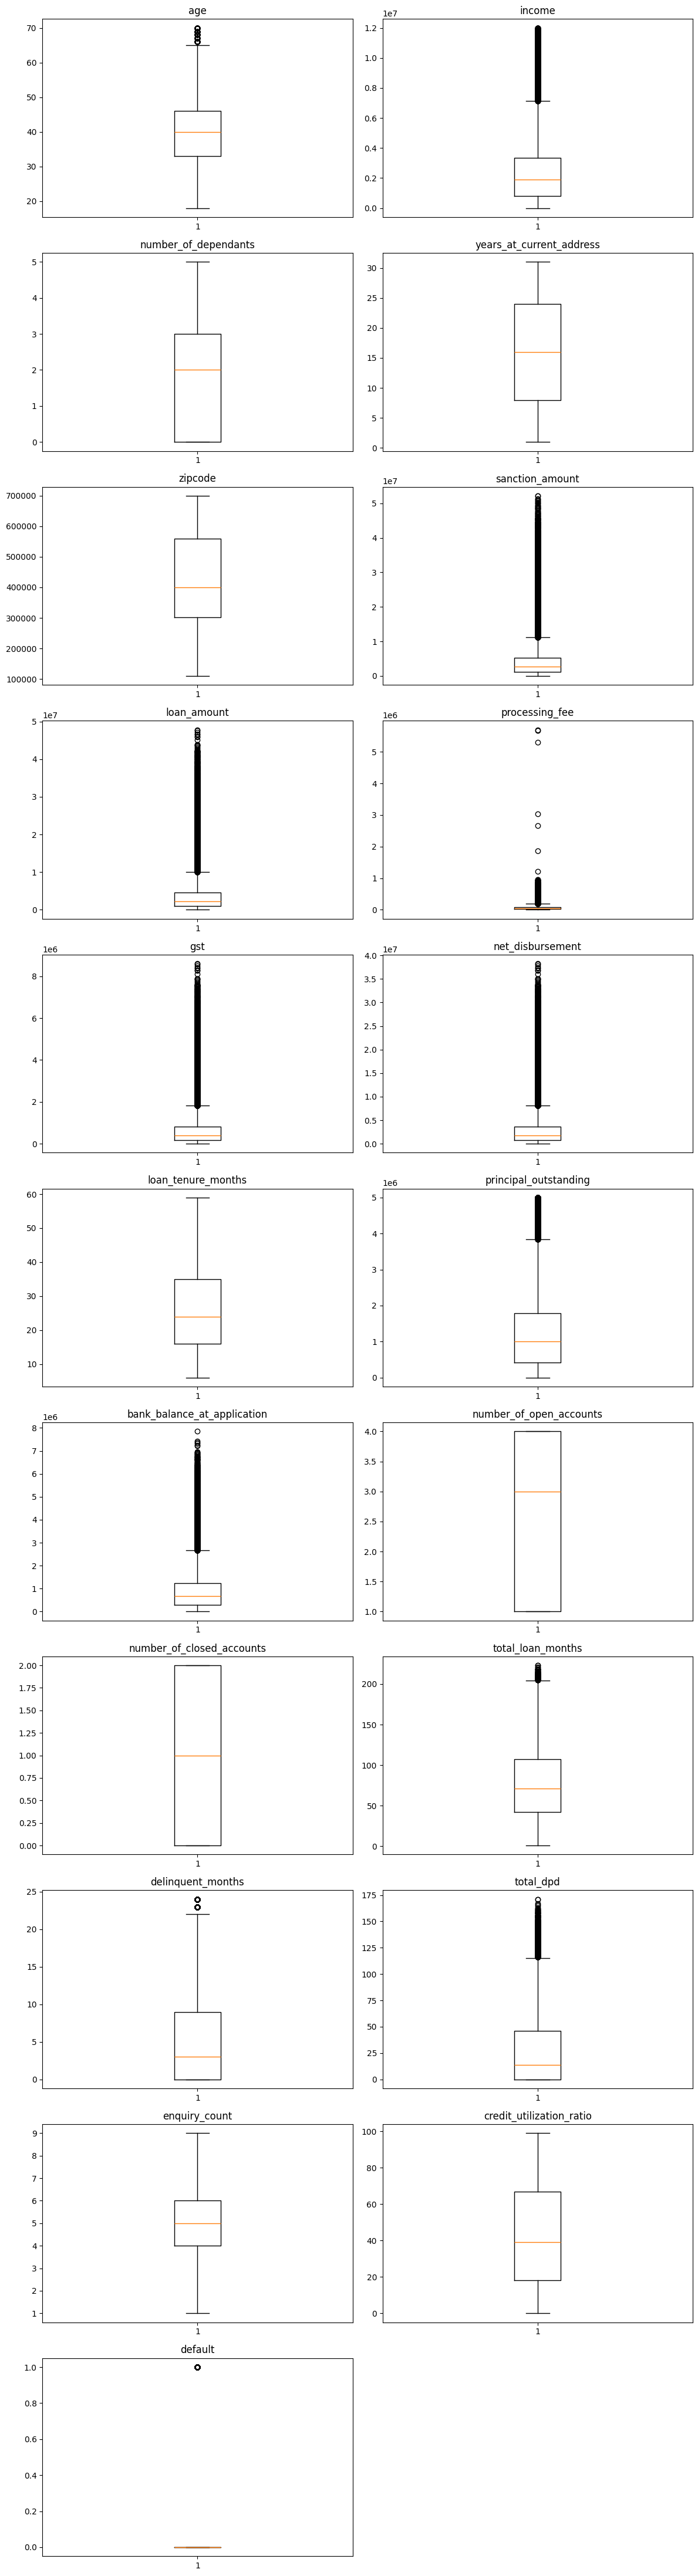

In [29]:
import matplotlib.pyplot as plt

num_cols = Numerical_cols
n = len(num_cols)

plt.figure(figsize=(12, 4 * ((n + 1) // 2)))

for i, col in enumerate(num_cols):
    plt.subplot((n + 1) // 2, 2, i + 1)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

#### 4. Handling Preprocessing Fee Outlier

In [30]:
df_train.processing_fee.describe()

count    3.750000e+04
mean     8.072411e+04
std      1.208307e+05
min      0.000000e+00
25%      1.918000e+04
50%      4.470000e+04
75%      9.200000e+04
max      5.698030e+06
Name: processing_fee, dtype: float64

In [31]:
df_train[(df_train.processing_fee/df_train.loan_amount) > 0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,2.669791e+06
9898,3626000,5.293544e+06
47089,1738000,1.858965e+06
33705,3812000,5.678021e+06
12294,4639000,5.698030e+06
28174,966000,1.214493e+06
29305,2616000,3.036378e+06


In [32]:
df_train_preprocessed = df_train[(df_train.processing_fee/df_train.loan_amount) < 0.03].copy()
df_train_preprocessed[(df_train_preprocessed.processing_fee/df_train.loan_amount) > 0.03][['loan_amount','processing_fee']]

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21332\2965042104.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train_preprocessed[(df_train_preprocessed.processing_fee/df_train.loan_amount) > 0.03][['loan_amount','processing_fee']]


,loan_amount,processing_fee


In [33]:
df_test_preprocessed = df_test[(df_test.processing_fee/df_test.loan_amount) < 0.03].copy()
df_test_preprocessed[(df_test_preprocessed.processing_fee/df_test_preprocessed.loan_amount) > 0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee


If the ratio of Processing_fee/loan_amount ratio is greater than 0.03, it is a outlier

#### 5. Handling misspelled values in loan_purpose column

In [34]:
for col in Categorical_cols:
    print(f"Unique values in {col} column:", df_train_preprocessed[col].unique().tolist())

Unique values in cust_id column: ['C27435', 'C13401', 'C00884', 'C07304', 'C45125', 'C00875', 'C45944', 'C11459', 'C23878', 'C00012', 'C27814', 'C10714', 'C46015', 'C03646', 'C10449', 'C41969', 'C03814', 'C04524', 'C07232', 'C39424', 'C46648', 'C12548', 'C10918', 'C16905', 'C39864', 'C24729', 'C12696', 'C36115', 'C29695', 'C07529', 'C28809', 'C04757', 'C30433', 'C01109', 'C11091', 'C42877', 'C28137', 'C19861', 'C08055', 'C05887', 'C44552', 'C03543', 'C08360', 'C15075', 'C40590', 'C19529', 'C02334', 'C37769', 'C37792', 'C22895', 'C11791', 'C43629', 'C47119', 'C17704', 'C14475', 'C22428', 'C28884', 'C05786', 'C27396', 'C05884', 'C37912', 'C07003', 'C08802', 'C39804', 'C46758', 'C34685', 'C17118', 'C31533', 'C00269', 'C03143', 'C04801', 'C35869', 'C07423', 'C21414', 'C04397', 'C02157', 'C28373', 'C32051', 'C01442', 'C25016', 'C25073', 'C27122', 'C49883', 'C19547', 'C35894', 'C13906', 'C32948', 'C15559', 'C06528', 'C49723', 'C17488', 'C37635', 'C16967', 'C12859', 'C48445', 'C11147', 'C2405

### 6. Converting Zipcode to str type

In [35]:
df_train_preprocessed['zipcode'] = df_train_preprocessed['zipcode'].astype(str)
df_test_preprocessed['zipcode'] = df_test_preprocessed['zipcode'].astype(str)

### 7. The column loan_purpose have two Personal unique values

In [36]:
df_train_preprocessed['loan_purpose'] = df_train_preprocessed['loan_purpose'].replace('Personaal','Personal')
df_test_preprocessed['loan_purpose'] = df_test_preprocessed['loan_purpose'].replace('Personaal','Personal')

In [39]:
df_train_preprocessed.info()

<class 'pandas.DataFrame'>
Index: 37487 entries, 27434 to 15795
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37487 non-null  str    
 1   age                          37487 non-null  int64  
 2   gender                       37487 non-null  str    
 3   marital_status               37487 non-null  str    
 4   employment_status            37487 non-null  str    
 5   income                       37487 non-null  int64  
 6   number_of_dependants         37487 non-null  int64  
 7   residence_type               37487 non-null  str    
 8   years_at_current_address     37487 non-null  int64  
 9   city                         37487 non-null  str    
 10  state                        37487 non-null  str    
 11  zipcode                      37487 non-null  str    
 12  loan_id                      37487 non-null  str    
 13  loan_purpose                

In [37]:
os.makedirs('D:\\Credit Risk Modelling\\Data\\processed', exist_ok=True)
df_train_preprocessed.to_csv('D:\\Credit Risk Modelling\\Data\\processed\\train_processed.csv', index=False)
df_test_preprocessed.to_csv('D:\\Credit Risk Modelling\\Data\\processed\\test_processed.csv', index=False)

In [38]:
y_train.to_csv('D:\\Credit Risk Modelling\\Data\\processed\\y_train.csv', index=False)
y_test.to_csv('D:\\Credit Risk Modelling\\Data\\processed\\y_test.csv', index=False)